In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
df = pd.read_csv("Summary of Weather.csv")

C:\Users\altin\AppData\Local\Temp\ipykernel_19600\2360501030.py:1: DtypeWarning: Columns (7,8,18,25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Summary of Weather.csv")


In [3]:
df.isnull().sum()

STA                 0
Date                0
Precip              0
WindGustSpd    118508
MaxTemp             0
MinTemp             0
MeanTemp            0
Snowfall         1163
PoorWeather     84803
YR                  0
MO                  0
DA                  0
PRCP             1932
DR             118507
SPD            118508
MAX               474
MIN               468
MEA               498
SNF              1163
SND            113477
FT             119040
FB             119040
FTI            119040
ITH            119040
PGT            118515
TSHDSBRSGF      84803
SD3            119040
RHX            119040
RHN            119040
RVG            119040
WTE            119040
dtype: int64

In [4]:
df.dropna(axis=1, how='all', inplace=True)
df.isnull().sum()

STA                 0
Date                0
Precip              0
WindGustSpd    118508
MaxTemp             0
MinTemp             0
MeanTemp            0
Snowfall         1163
PoorWeather     84803
YR                  0
MO                  0
DA                  0
PRCP             1932
DR             118507
SPD            118508
MAX               474
MIN               468
MEA               498
SNF              1163
SND            113477
PGT            118515
TSHDSBRSGF      84803
dtype: int64

In [5]:
df.drop(['WindGustSpd', 'DR', 'SPD', 'SND', 'PGT', 'MAX', 'MIN', 'MEA', 'PRCP', 'SNF'], axis=1, inplace=True)
df.isnull().sum()

STA                0
Date               0
Precip             0
MaxTemp            0
MinTemp            0
MeanTemp           0
Snowfall        1163
PoorWeather    84803
YR                 0
MO                 0
DA                 0
TSHDSBRSGF     84803
dtype: int64

In [6]:
df.drop(['TSHDSBRSGF'], axis=1, inplace=True)

In [7]:
df.isnull().sum()

STA                0
Date               0
Precip             0
MaxTemp            0
MinTemp            0
MeanTemp           0
Snowfall        1163
PoorWeather    84803
YR                 0
MO                 0
DA                 0
dtype: int64

In [8]:
df.head()

,STA,Date,Precip,MaxTemp,MinTemp,MeanTemp,Snowfall,PoorWeather,YR,MO,DA
0,10001,1942-7-1,1.016,25.555556,22.222222,23.888889,0.0,NaN,42,7,1
1,10001,1942-7-2,0,28.888889,21.666667,25.555556,0.0,NaN,42,7,2
2,10001,1942-7-3,2.54,26.111111,22.222222,24.444444,0.0,NaN,42,7,3
3,10001,1942-7-4,2.54,26.666667,22.222222,24.444444,0.0,NaN,42,7,4
4,10001,1942-7-5,0,26.666667,21.666667,24.444444,0.0,NaN,42,7,5


In [9]:
df.drop('PoorWeather', axis=1, inplace=True)

In [10]:
df['Snowfall'].fillna(0, inplace=True) 
df.isnull().sum()

STA         0
Date        0
Precip      0
MaxTemp     0
MinTemp     0
MeanTemp    0
Snowfall    0
YR          0
MO          0
DA          0
dtype: int64

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119040 entries, 0 to 119039
Data columns (total 10 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   STA       119040 non-null  int64  
 1   Date      119040 non-null  object 
 2   Precip    119040 non-null  object 
 3   MaxTemp   119040 non-null  float64
 4   MinTemp   119040 non-null  float64
 5   MeanTemp  119040 non-null  float64
 6   Snowfall  119040 non-null  object 
 7   YR        119040 non-null  int64  
 8   MO        119040 non-null  int64  
 9   DA        119040 non-null  int64  
dtypes: float64(3), int64(4), object(3)
memory usage: 9.1+ MB


In [12]:
df['Snowfall'] = df['Snowfall'].replace('T', 0) 
df['Snowfall'] = df['Snowfall'].replace('#VALUE!', 0) 
df['Snowfall'] = pd.to_numeric(df['Snowfall'])
df['Date'] = pd.to_datetime(df['Date'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119040 entries, 0 to 119039
Data columns (total 10 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   STA       119040 non-null  int64         
 1   Date      119040 non-null  datetime64[ns]
 2   Precip    119040 non-null  object        
 3   MaxTemp   119040 non-null  float64       
 4   MinTemp   119040 non-null  float64       
 5   MeanTemp  119040 non-null  float64       
 6   Snowfall  119040 non-null  float64       
 7   YR        119040 non-null  int64         
 8   MO        119040 non-null  int64         
 9   DA        119040 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(4), object(1)
memory usage: 9.1+ MB


In [13]:
df['Precip'].unique()

array(['1.016', '0', '2.54', 'T', '3.556', '0.508', '0.254', '1.778',
       '3.302', '0.762', '5.588', '5.08', '2.032', '25.654', '40.132',
       '19.05', '23.876', '4.064', '12.192', '2.794', '33.274', '19.304',
       '47.752', '6.35', '3.048', '8.382', '10.16', '27.178', '30.48',
       '45.212', '10.668', '15.494', '57.658', '58.166', '11.43',
       '31.242', '17.78', '26.924', '26.67', '6.604', '5.334', '4.826',
       '7.62', '8.636', '7.874', '12.446', '90.932', '13.462', '11.938',
       '5.842', '4.318', '6.096', '9.144', '4.572', '9.906', '9.652',
       '1.524', '13.97', '17.272', '33.528', '1.27', '13.716', '8.128',
       '22.352', '39.116', '36.068', '98.044', '3.81', '14.986', '78.232',
       '146.304', '14.732', '21.844', '120.904', '42.164', '23.368',
       '21.082', '44.958', '2.286', '50.038', '17.526', '51.054', '7.112',
       '25.4', '7.366', '16.256', '46.736', '8.89', '24.638', '11.684',
       '17.018', '144.78', '18.034', '50.8', '106.426', '36.576', '53.

In [14]:
df['Precip'] = df['Precip'].replace('T', 0) 
df['Precip'] = pd.to_numeric(df['Precip'])
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119040 entries, 0 to 119039
Data columns (total 10 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   STA       119040 non-null  int64         
 1   Date      119040 non-null  datetime64[ns]
 2   Precip    119040 non-null  float64       
 3   MaxTemp   119040 non-null  float64       
 4   MinTemp   119040 non-null  float64       
 5   MeanTemp  119040 non-null  float64       
 6   Snowfall  119040 non-null  float64       
 7   YR        119040 non-null  int64         
 8   MO        119040 non-null  int64         
 9   DA        119040 non-null  int64         
dtypes: datetime64[ns](1), float64(5), int64(4)
memory usage: 9.1 MB


In [15]:
print(df.duplicated().sum())

10


In [16]:
df.drop_duplicates(inplace=True)

In [17]:
df.describe()

,STA,Date,Precip,MaxTemp,MinTemp,MeanTemp,Snowfall,YR,MO,DA
count,119030.000000,119030,119030.000000,119030.000000,119030.000000,119030.000000,119030.000000,119030.000000,119030.000000,119030.000000
mean,29659.059456,1944-04-27 15:43:51.450894848,3.225847,27.044545,17.789446,22.411320,0.243074,43.805184,6.726077,15.796715
min,10001.000000,1940-01-01 00:00:00,0.000000,-33.333333,-38.333333,-35.555556,0.000000,40.000000,1.000000,1.000000
25%,11801.000000,1943-09-03 00:00:00,0.000000,25.555556,15.000000,20.555556,0.000000,43.000000,4.000000,8.000000
50%,22508.000000,1944-06-26 00:00:00,0.000000,29.444444,21.111111,25.555556,0.000000,44.000000,7.000000,16.000000
75%,33501.000000,1945-03-15 00:00:00,0.762000,31.666667,23.333333,27.222222,0.000000,45.000000,10.000000,23.000000
max,82506.000000,1945-12-31 00:00:00,307.340000,50.000000,34.444444,40.000000,86.360000,45.000000,12.000000,31.000000
std,20954.049325,NaN,10.801465,8.717924,8.334910,8.298256,2.613475,1.136713,3.425698,8.794421


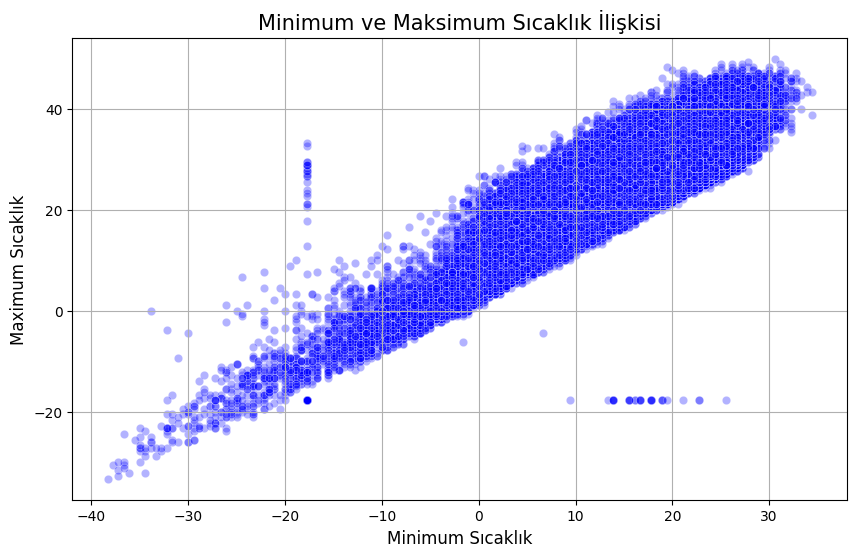

In [18]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='MinTemp', y='MaxTemp', data=df, color='blue', alpha=0.3)
plt.title('Minimum ve Maksimum Sıcaklık İlişkisi', fontsize=15)
plt.xlabel('Minimum Sıcaklık', fontsize=12)
plt.ylabel('Maximum Sıcaklık', fontsize=12)
plt.grid(True)
plt.show()


In [19]:
df = df[df['MinTemp'] <= df['MaxTemp']]
df = df[(df['MaxTemp'] - df['MinTemp']) <= 35]
print(len(df))

118975


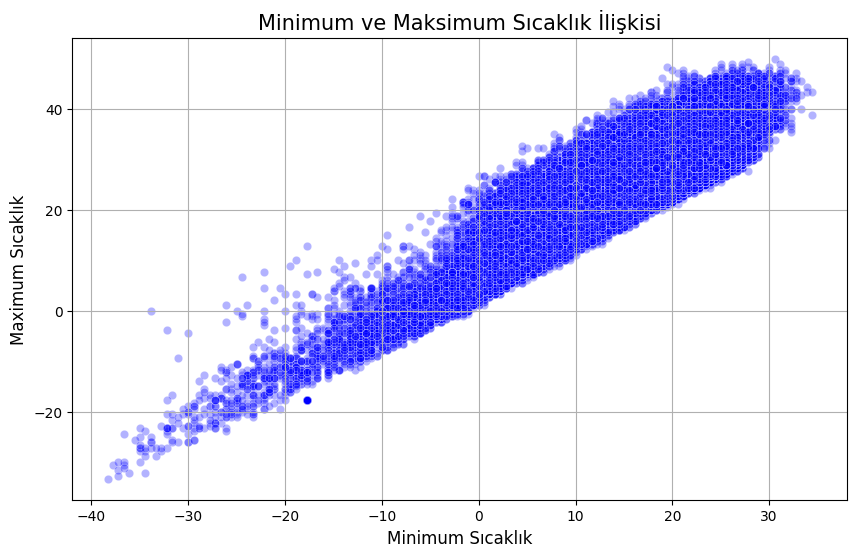

In [20]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='MinTemp', y='MaxTemp', data=df, color='blue', alpha=0.3)
plt.title('Minimum ve Maksimum Sıcaklık İlişkisi', fontsize=15)
plt.xlabel('Minimum Sıcaklık', fontsize=12)
plt.ylabel('Maximum Sıcaklık', fontsize=12)
plt.grid(True)
plt.show()

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

In [22]:
scaler = StandardScaler()

In [23]:
y = df['MaxTemp']
X = df[['MinTemp']]

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

<Axes: >

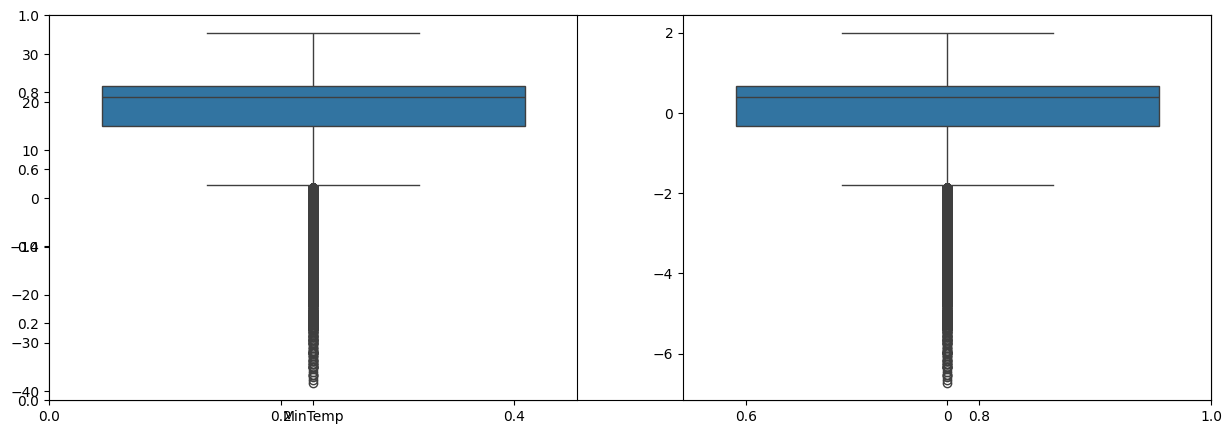

In [26]:
plt.subplots(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(data=X_train)
plt.subplot(1,2,2)
sns.boxplot(data=X_train_scaled)


In [27]:
linear = LinearRegression()

In [28]:
linear.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [29]:
y_pred = linear.predict(X_test_scaled)

In [30]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
score = r2_score(y_test, y_pred)

r2 score :  0.773688279389947
mae :  3.1669396788134576
mse :  16.68387238101401


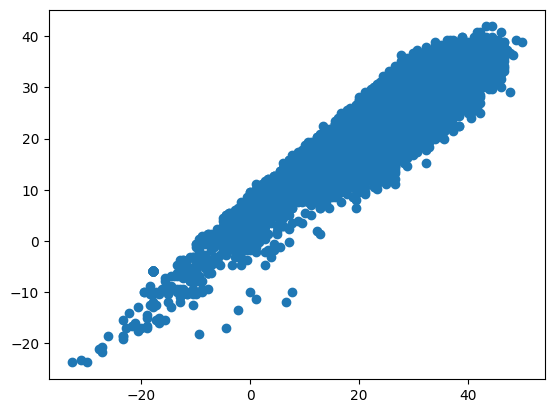

In [31]:
plt.scatter(y_test, y_pred)
print("r2 score : ", score)
print("mae : ", mae)
print("mse : ", mse)

In [32]:
from lazypredict.Supervised import LazyRegressor

In [33]:
reg = LazyRegressor(verbose=0, ignore_warnings=False, custom_metric=None)

In [ ]:
models, predictions = reg.fit(X_train, X_test, y_train, y_test)

In [ ]:
models

,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
GradientBoostingRegressor,0.811811,0.811819,3.724632,2.043124
HistGradientBoostingRegressor,0.811737,0.811745,3.725360,3.702966
XGBRegressor,0.811640,0.811648,3.726321,0.309060
DecisionTreeRegressor,0.811638,0.811646,3.726336,0.023794
ExtraTreesRegressor,0.811635,0.811643,3.726367,0.913819
ExtraTreeRegressor,0.811631,0.811639,3.726410,0.015771
RandomForestRegressor,0.811618,0.811626,3.726540,1.343194
BaggingRegressor,0.811512,0.811520,3.727584,0.151786
MLPRegressor,0.809412,0.809420,3.748291,13.324646


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

In [ ]:
model_gbr = GradientBoostingRegressor(random_state=42)

In [ ]:
model_gbr.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [ ]:
y_pred_gbr = model_gbr.predict(X_test)

In [ ]:
r2_gbr = r2_score(y_test, y_pred_gbr)

In [ ]:
n = len(X_test)
p = X_test.shape[1]
adj_r2_gbr = 1 - ((1 - r2_gbr) * (n - 1) / (n - p - 1))

In [ ]:

print(f"Baştaki Lineer Regresyon Puanı: 0.7737")
print("-" * 50)
print(f"Yeni (Şampiyon) R2 Skoru         : {r2_gbr:.4f}")
print(f"Yeni Düzeltilmiş R2 Skoru        : {adj_r2_gbr:.4f}")

Baştaki Lineer Regresyon Puanı: 0.7737
--------------------------------------------------
Yeni (Şampiyon) R2 Skoru         : 0.8118
Yeni Düzeltilmiş R2 Skoru        : 0.8118
